# Artificial Partial-Graph Token Reconstruction

This notebook tests graph-to-graph reconstruction: a randomly reduced artificial graph is encoded as node-token conditioning, and the model learns to reconstruct the original full graph.

This notebook trains a reconstruction setup on artificial graphs where the condition is a partial graph, not a graph-level vector from the same full graph.

Workflow:

1. generate full artificial graphs,
2. remove a user-defined fraction of nodes from each graph,
3. encode the partial graphs with the node transformer/vectorizer and the fitted node SVD,
4. pass those partial-graph node embeddings as cross-attention memory tokens,
5. train the node field on the full graph node embeddings and full-graph supervision heads.

The conditioning token rows are not assumed to align with output node rows. This is the graph-to-graph special case of a more general domain-transfer setup where conditioning and output graphs may use different node sets.

In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import sys
from IPython.core.display import HTML
from pathlib import Path
import random
import warnings
import numpy as np
import networkx as nx

HTML('<style>.container { width:95% !important; }</style><style>.output_png {display: table-cell; text-align: center; vertical-align: middle;}</style>')
warnings.filterwarnings('ignore', message=r".*`isinstance\(treespec, LeafSpec\)` is deprecated.*")

for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / 'conditional_node_field_graph_generator').is_dir():
        repo_root = candidate.resolve()
        break
else:
    raise RuntimeError('Could not locate the NodeField repository from the current working directory.')

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from conditional_node_field_graph_generator.notebooks import configure_notebook
globals().update(configure_notebook(require_nsppk=True, print_torch=True))

from conditional_node_field_graph_generator.conditional_node_field_generator import GraphConditioningBatch
from conditional_node_field_graph_generator.extensions.demo.pipeline import build_graph_generator
from conditional_node_field_graph_generator.extensions.demo.artificial import generate_artificial_dataset


PyTorch version: 2.13.0
CUDA available: False


In [2]:
RANDOM_SEED = 42
DATASET_SIZE = 900
REMOVE_NODE_FRACTION = 0.50
MIN_PARTIAL_NODES = 1

CYCLE_LENGTH = 4
NUM_CYCLES = 1
PATH_LENGTH = (2, 6)
NUM_RAYS = 2
RAY_LENGTH = 1
NODE_ALPHABET_SIZE = 3
EDGE_ALPHABET_SIZE = 1
NODE_ALPHABET_KIND = 'int'
EDGE_ALPHABET_KIND = 'int'
COMPONENT_SPECIFIC_ALPHABETS = True

FIT_BATCH_SIZE = 128
MAXIMUM_EPOCHS = 350
LOSS_CURVES_PDF_EVERY_N_EPOCHS = 10
EMBEDDING_DIM = 128
DECODER_N_JOBS = -1

MODEL_NAME = (
    f'artificial-partial-token-reconstruct-n{DATASET_SIZE}'
    f'-remove{int(REMOVE_NODE_FRACTION * 100)}'
    f'-d{EMBEDDING_DIM}-b{FIT_BATCH_SIZE}-e{MAXIMUM_EPOCHS}'
)

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


Saved artificial dataset config: artificial-cycle-path-star-n900-c4-p2-6-r2x1-na3.yaml
Loaded 900 full artificial graphs.
Full node count min/median/max = 9/11/13
Full edge count min/median/max = 9/11/13


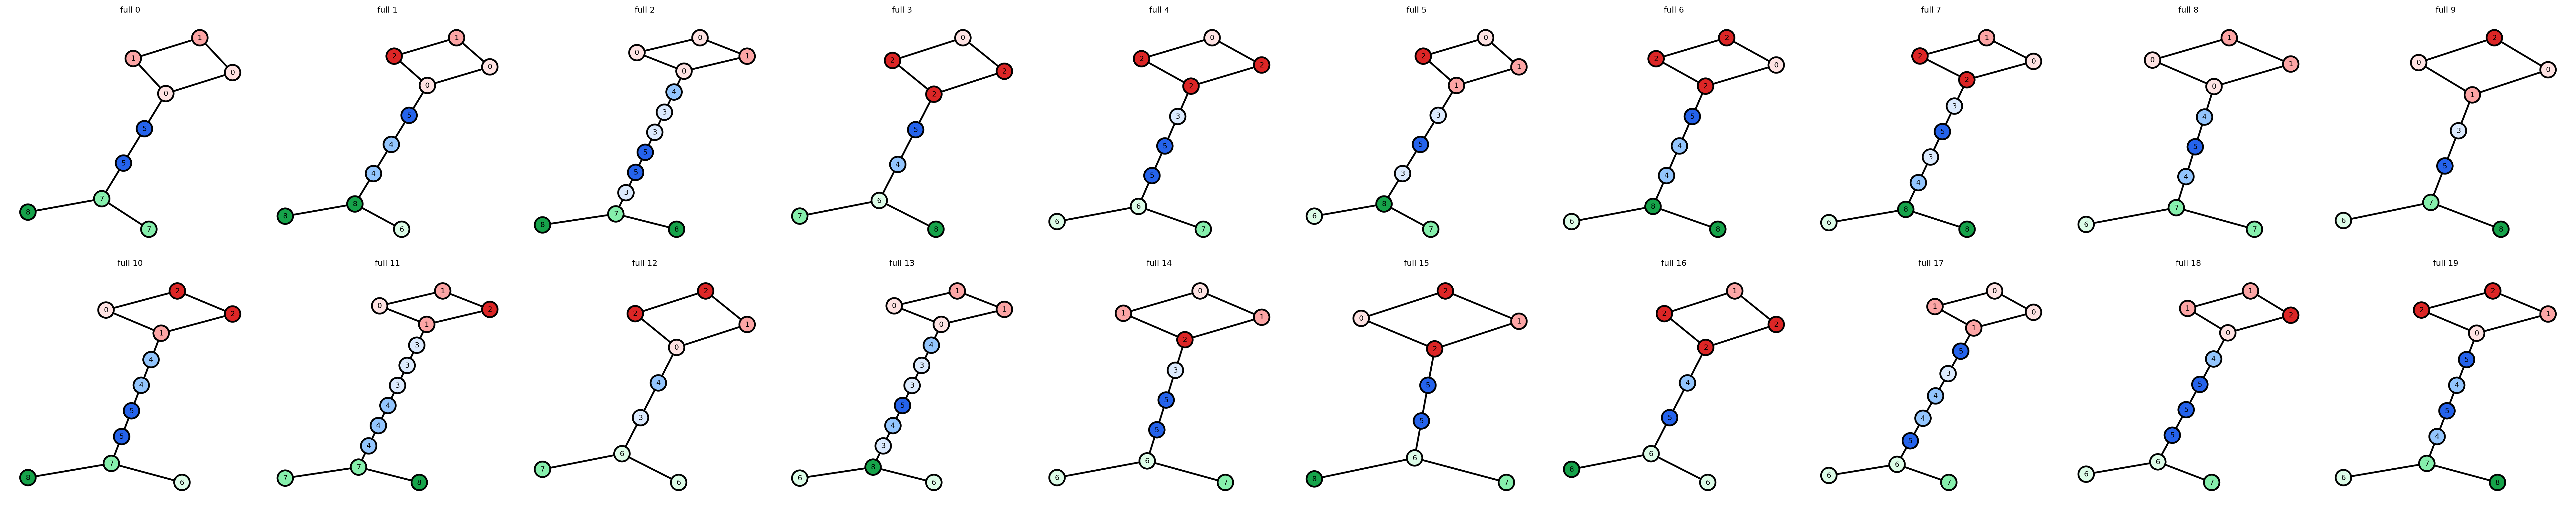

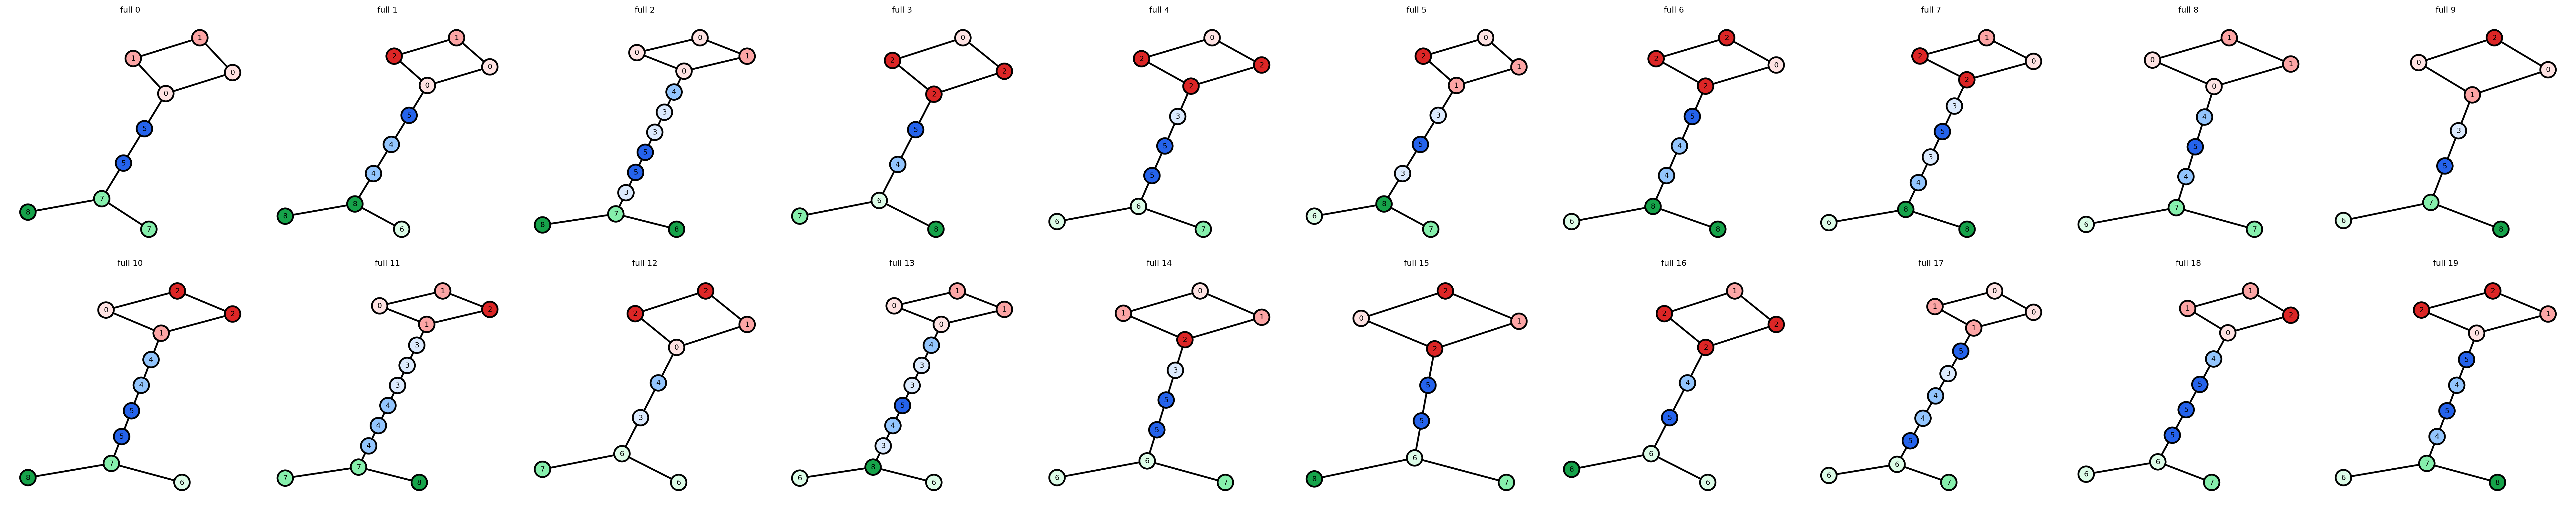

In [3]:
graphs, plot_artificial_graphs = generate_artificial_dataset(
    num_graphs=DATASET_SIZE,
    cycle_length=CYCLE_LENGTH,
    num_cycles=NUM_CYCLES,
    path_length=PATH_LENGTH,
    num_rays=NUM_RAYS,
    ray_length=RAY_LENGTH,
    node_alphabet_size=NODE_ALPHABET_SIZE,
    edge_alphabet_size=EDGE_ALPHABET_SIZE,
    node_alphabet_kind=NODE_ALPHABET_KIND,
    edge_alphabet_kind=EDGE_ALPHABET_KIND,
    component_specific_alphabets=COMPONENT_SPECIFIC_ALPHABETS,
    seed=RANDOM_SEED,
    save_config_dir=REPO_ROOT / 'notebooks' / 'configs' / 'artificial_datasets',
)

node_counts = np.array([graph.number_of_nodes() for graph in graphs])
edge_counts = np.array([graph.number_of_edges() for graph in graphs])
print(f'Loaded {len(graphs)} full artificial graphs.')
print(f'Full node count min/median/max = {node_counts.min()}/{np.median(node_counts):.0f}/{node_counts.max()}')
print(f'Full edge count min/median/max = {edge_counts.min()}/{np.median(edge_counts):.0f}/{edge_counts.max()}')

plot_artificial_graphs(
    graphs[:20],
    n_cols=10,
    titles=[f'full {idx}' for idx in range(20)],
)


Partial node count min/median/max = 5/5/7
Partial edge count min/median/max = 0/3/6


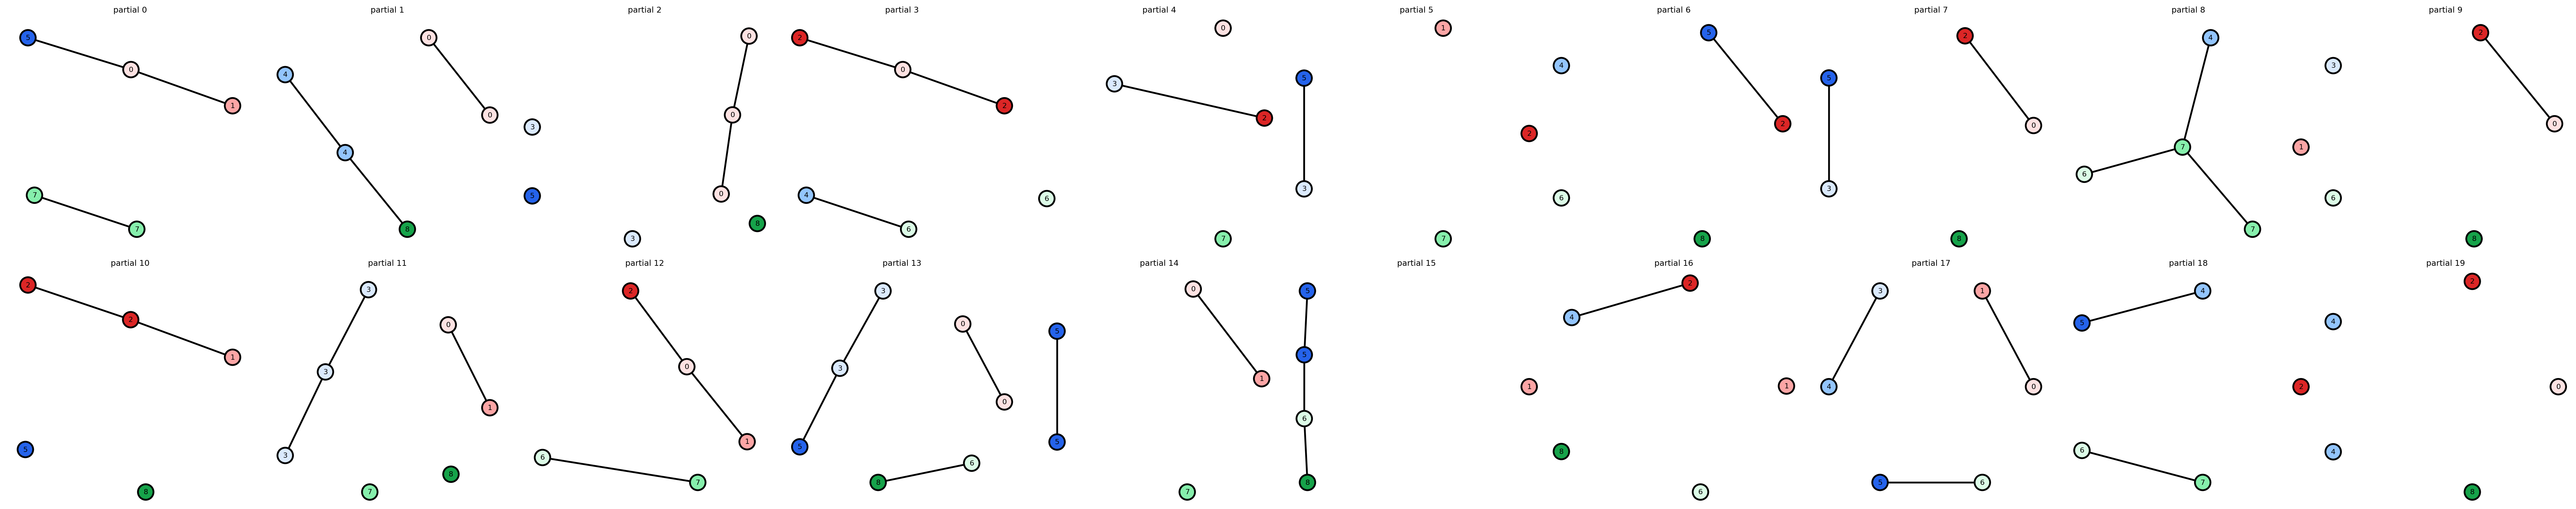

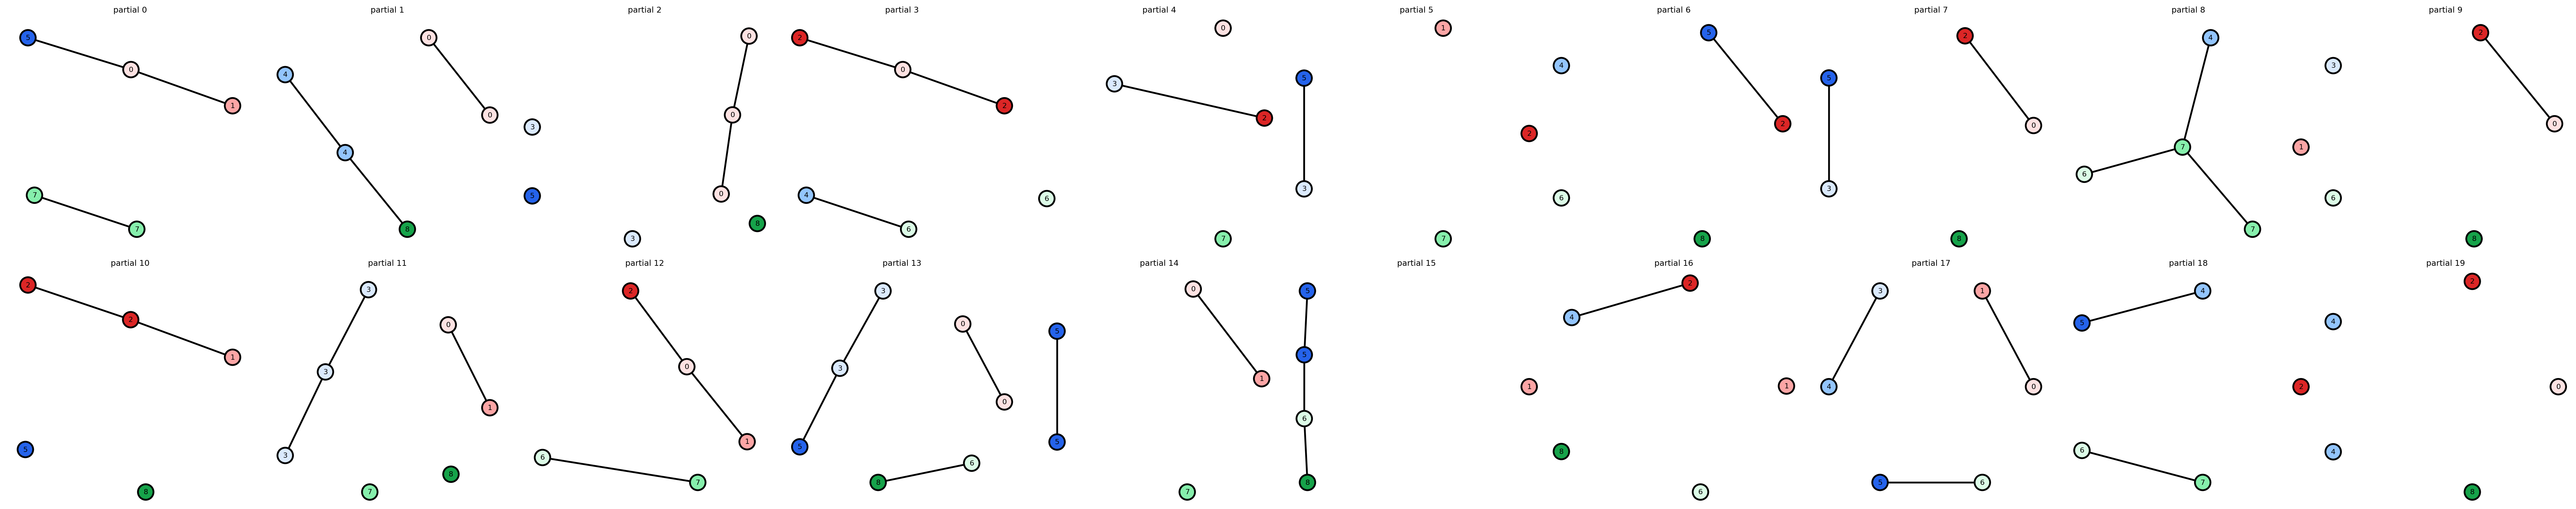

In [4]:
def make_partial_graph(graph, remove_fraction, rng, min_nodes=1):
    partial = graph.copy()
    nodes = list(partial.nodes())
    if not nodes:
        return partial
    remove_count = int(round(len(nodes) * float(remove_fraction)))
    remove_count = max(0, min(remove_count, len(nodes) - int(min_nodes)))
    if remove_count == 0:
        return partial
    remove_nodes = rng.choice(nodes, size=remove_count, replace=False).tolist()
    partial.remove_nodes_from(remove_nodes)
    partial.graph['removed_nodes'] = remove_nodes
    partial.graph['source_node_count'] = len(nodes)
    return partial


rng = np.random.default_rng(RANDOM_SEED)
partial_graphs = [
    make_partial_graph(graph, REMOVE_NODE_FRACTION, rng, min_nodes=MIN_PARTIAL_NODES)
    for graph in graphs
]

partial_node_counts = np.array([graph.number_of_nodes() for graph in partial_graphs])
partial_edge_counts = np.array([graph.number_of_edges() for graph in partial_graphs])
print(f'Partial node count min/median/max = {partial_node_counts.min()}/{np.median(partial_node_counts):.0f}/{partial_node_counts.max()}')
print(f'Partial edge count min/median/max = {partial_edge_counts.min()}/{np.median(partial_edge_counts):.0f}/{partial_edge_counts.max()}')

plot_artificial_graphs(
    partial_graphs[:20],
    n_cols=10,
    titles=[f'partial {idx}' for idx in range(20)],
)


In [5]:
graph_generator = build_graph_generator(
    latent_embedding_dimension=EMBEDDING_DIM,
    node_embedding_svd_dimension=EMBEDDING_DIM,
    graph_embedding_svd_dimension=EMBEDDING_DIM,
    number_of_transformer_layers=3,
    transformer_attention_head_count=4,
    locality_horizon=2,
    sparse_supervision_mask_ratio=0.5,
    maximum_epochs=MAXIMUM_EPOCHS,
    batch_size=FIT_BATCH_SIZE,
    verbose=1,
    decoder_n_jobs=DECODER_N_JOBS,
    artifact_root=ARTIFACT_ROOT,
    checkpoint_root=CHECKPOINT_ROOT,
    model_name=MODEL_NAME,
    model_dir=SAVED_GENERATOR_ROOT,
)
graph_generator.loss_curves_pdf_every_n_epochs = LOSS_CURVES_PDF_EVERY_N_EPOCHS

def render_artificial_graphs(decoded_graphs, **kwargs):
    graph_list = list(decoded_graphs)
    plot_artificial_graphs(
        graph_list,
        n_cols=max(1, min(7, len(graph_list))),
        titles=kwargs.get('titles'),
    )


graph_generator.graph_decoder.diagnostic_graph_renderer = render_artificial_graphs
TRAINING_PROGRESS_PDF_PATH = ARTIFACT_ROOT / 'samples' / MODEL_NAME / 'training_samples.pdf'
print(f'Training sample PDF: {TRAINING_PROGRESS_PDF_PATH}')


Configured graph generator model_name=artificial-partial-token-reconstruct-n900-remove50-d128-b128-e350 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Training sample PDF: /Users/f.costa/Code/NodeField/.artifacts/samples/artificial-partial-token-reconstruct-n900-remove50-d128-b128-e350/training_samples.pdf


In [6]:
%%time
# Fit vectorizers, SVDs, decoder, label vocabularies, and supervision plan on the full target graphs.
# The node generator is trained manually below with tokenized partial-graph conditioning.
graph_generator.fit(graphs, train_node_generator=False)

full_node_embeddings = graph_generator.node_encode(graphs)
partial_node_embeddings = graph_generator.node_encode(partial_graphs)

node_label_targets = graph_generator.graphs_to_node_label_targets(graphs)
edge_label_targets, edge_label_pairs = graph_generator.graphs_to_edge_label_targets(graphs)
node_batch = graph_generator._build_training_node_batch(
    graphs,
    node_embeddings_list=full_node_embeddings,
    node_label_targets=node_label_targets,
    edge_label_targets=edge_label_targets,
    edge_label_pairs=edge_label_pairs,
    supervision_plan=graph_generator.supervision_plan_,
)

max_condition_tokens = max(embedding.shape[0] for embedding in partial_node_embeddings)
condition_presence_mask = np.zeros((len(partial_node_embeddings), max_condition_tokens), dtype=bool)
for idx, embedding in enumerate(partial_node_embeddings):
    condition_presence_mask[idx, :embedding.shape[0]] = True

partial_graph_conditioning = GraphConditioningBatch(
    # Empty graph-level vector: conditioning structure comes from partial node tokens.
    graph_embeddings=np.zeros((len(graphs), 0), dtype=float),
    # Node/edge counts are the reconstruction targets for the full graph.
    node_counts=np.asarray([graph.number_of_nodes() for graph in graphs], dtype=np.int64),
    edge_counts=np.asarray([graph.number_of_edges() for graph in graphs], dtype=np.int64),
    condition_node_embeddings=partial_node_embeddings,
    condition_node_presence_mask=condition_presence_mask,
)

condition_array = graph_generator.conditional_node_generator_model._compose_condition_array(partial_graph_conditioning)
print('Full target node matrix count:', len(full_node_embeddings))
print('Condition token tensor shape:', condition_array.shape)
print('Node batch mask shape:', node_batch.node_presence_mask.shape)


Fit target model_name=artificial-partial-token-reconstruct-n900-remove50-d128-b128-e350 model_dir=/Users/f.costa/Code/NodeField/.artifacts/saved_generators
Fitting model on 900 graphs
Fitting graph vectorizer on 900 graphs
Finished fitting graph vectorizer on 900 graphs in 0m 0.0s
Fitting node graph vectorizer on 900 graphs
Finished fitting node graph vectorizer on 900 graphs in 0m 0.0s
Encoding node embeddings for 900 graphs
Finished encoding node embeddings for 900 graphs in 0m 1.1s
Encoding graph embeddings for 900 graphs
Finished encoding graph embeddings for 900 graphs in 0m 1.0s
Fitting embedding SVDs
Stacking raw node embeddings for SVD.
Stacked node embedding matrix: shape=(9990, 2048), sparse=True, nnz=1388491, density=0.067865.
Prepared graph embedding matrix: shape=(900, 2048), sparse=True, nnz=686808, density=0.372617.
Fitting node embedding SVD on shape=(9990, 2048), sparse=True, nnz=1388491, density=0.067865 to 128 dimensions.
Fitted node embedding SVD: 2048 -> 128.
Fitti

Lambda settings: degree=2.000, node_exist=2.000, node_count=0.500, node_label=2.000, edge_label=2.000, direct_edge=2.000, edge_count=0.500, deg_edge_consistency=0.500, aux_edge=1.000
Direct edge supervision enabled: horizon-1 edge presence will be learned and used by the decoder.
Soft edge-count supervision enabled: lambda_edge_count_importance=0.500.
Soft node-count supervision enabled: lambda_node_count_importance=0.500.
Degree/edge-count consistency supervision enabled: lambda_degree_edge_consistency_importance=0.500.
Auxiliary locality supervision enabled: higher-horizon locality pairs will be used only as an encoding regularizer.
Edge-label supervision enabled: discrete edge labels will be predicted by the generator.
Direct-edge BCE positive weight: 1.984.
Auxiliary-locality BCE positive weight: 1.484.
ANN size: parameters=1,241,364, trainable=1,241,364, parameter_size=4.97 MB, trainable_size=4.97 MB.
Save target model_name=artificial-partial-token-reconstruct-n900-remove50-d128-b

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores


Epoch 10/350 | ETA 0h 04m 35s:
  train total=   45.633 | node_field    24.762 [54.3%] |        deg    1.5827 [3.5%] |      exist   0.22698 [0.5%] | node_count   0.00325 [<0.1%]
  val   total=   44.537 | node_field    24.878 [55.9%] |        deg    1.4976 [3.4%] |      exist   0.25096 [0.6%] | node_count   0.00374 [<0.1%]
  train                 | node_label    3.6360 [8.0%] | edge_label    1.3035 [2.9%] |       edge    1.8252 [4.0%] | edge_count    11.474 [25.1%] | deg_edge_consistency   0.00015 [<0.1%]
  val                   | node_label    3.2380 [7.3%] | edge_label    1.0027 [2.3%] |       edge    1.7878 [4.0%] | edge_count    11.079 [24.9%] | deg_edge_consistency   0.00012 [<0.1%]
  train                 |        aux   0.81857 [1.8%] | dominant=node_field [54.3%]
  val                   |        aux   0.79868 [1.8%] | dominant=node_field [55.9%]
Epoch 20/350 | ETA 0h 04m 22s:
  train total=   40.223 | node_field    24.228 [60.2%] |        deg    1.1520 [2.9%] |      exist   0.2289

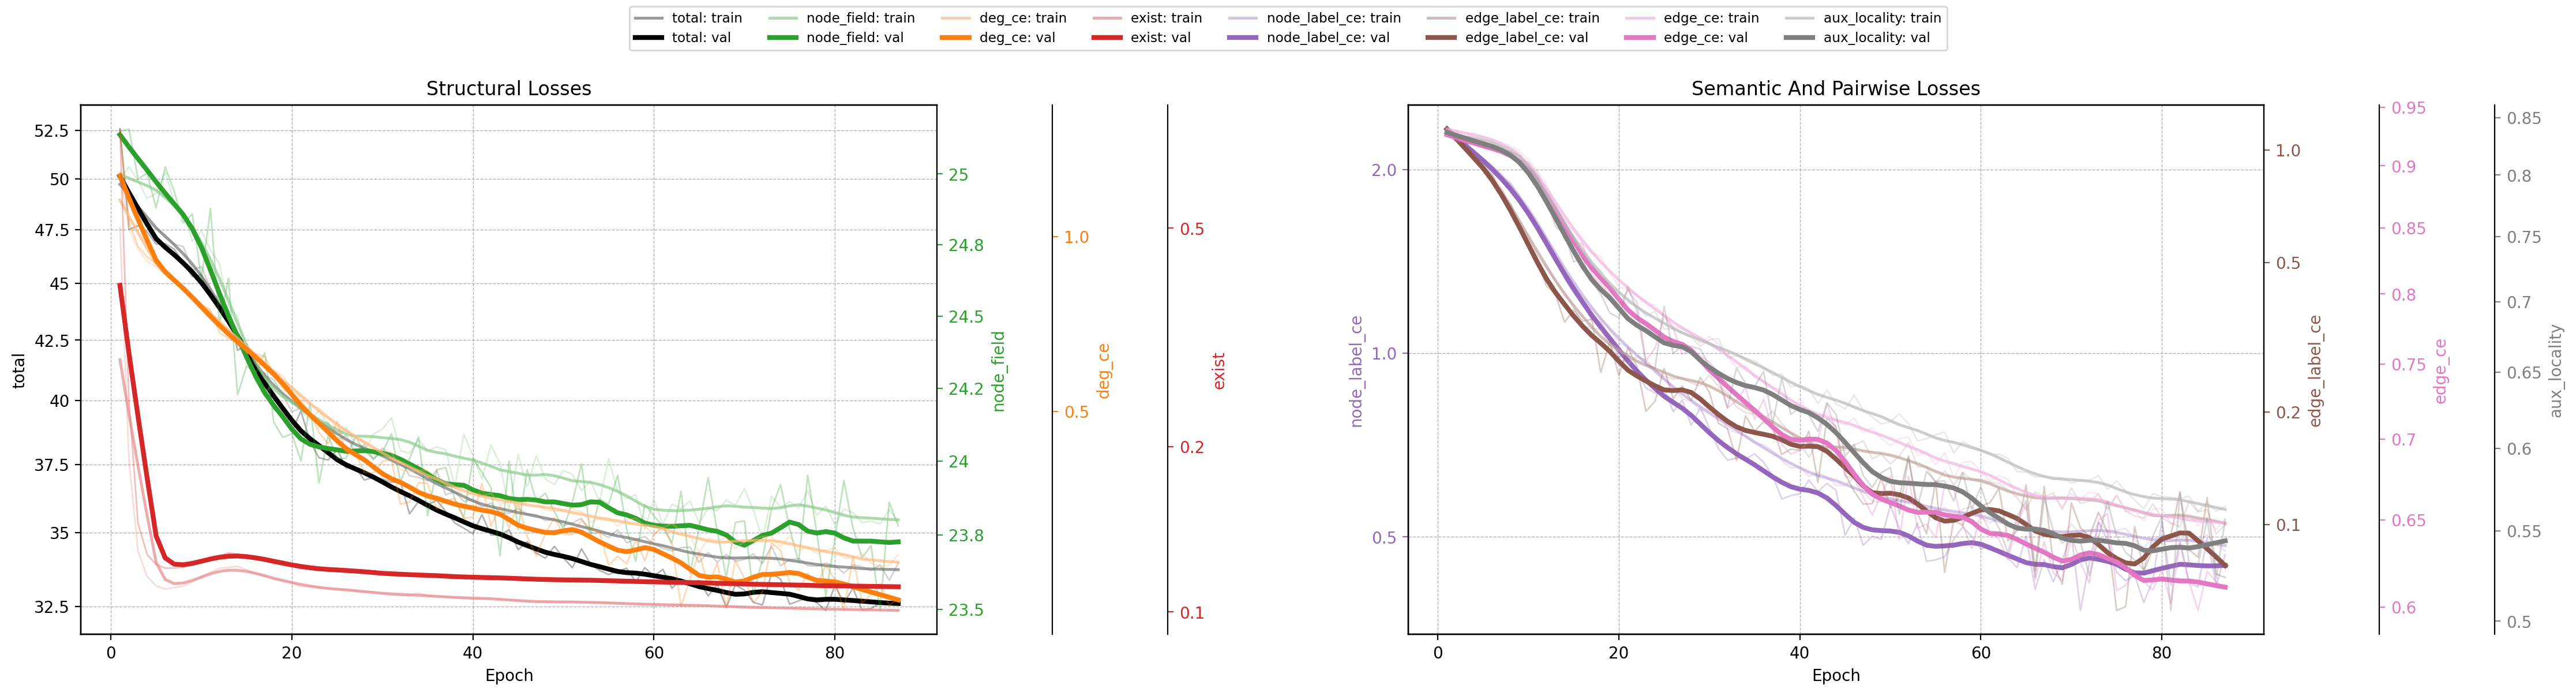

condition_token_count = 7
condition_feature_dimension = 131
is_fitted_ = True
CPU times: user 55.4 s, sys: 14.5 s, total: 1min 9s
Wall time: 1min 17s


In [7]:
%%time
graph_generator.conditional_node_generator_model.setup(
    node_batch=node_batch,
    graph_conditioning=partial_graph_conditioning,
)
setattr(graph_generator.conditional_node_generator_model, '_graph_generator_snapshot_owner', graph_generator)
setattr(
    graph_generator.conditional_node_generator_model,
    '_graph_generator_sample_progress_config',
    None,
)
graph_generator.conditional_node_generator_model.fit(
    node_batch=node_batch,
    graph_conditioning=partial_graph_conditioning,
)

graph_generator.training_graph_conditioning_ = partial_graph_conditioning
graph_generator.is_fitted_ = True
print('condition_token_count =', graph_generator.conditional_node_generator_model.condition_token_count)
print('condition_feature_dimension =', graph_generator.conditional_node_generator_model.condition_feature_dimension)
print('is_fitted_ =', graph_generator.is_fitted_)


Decoding 6 conditioning vectors


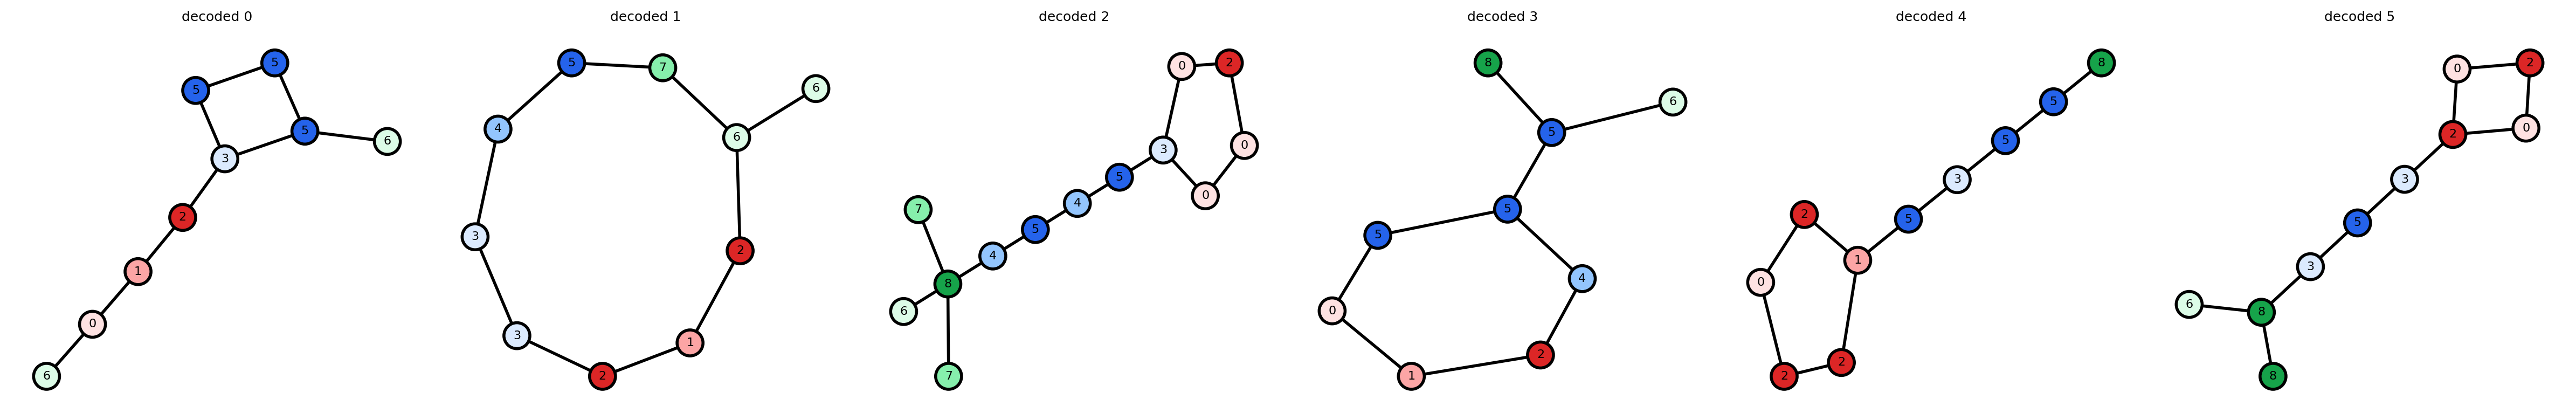

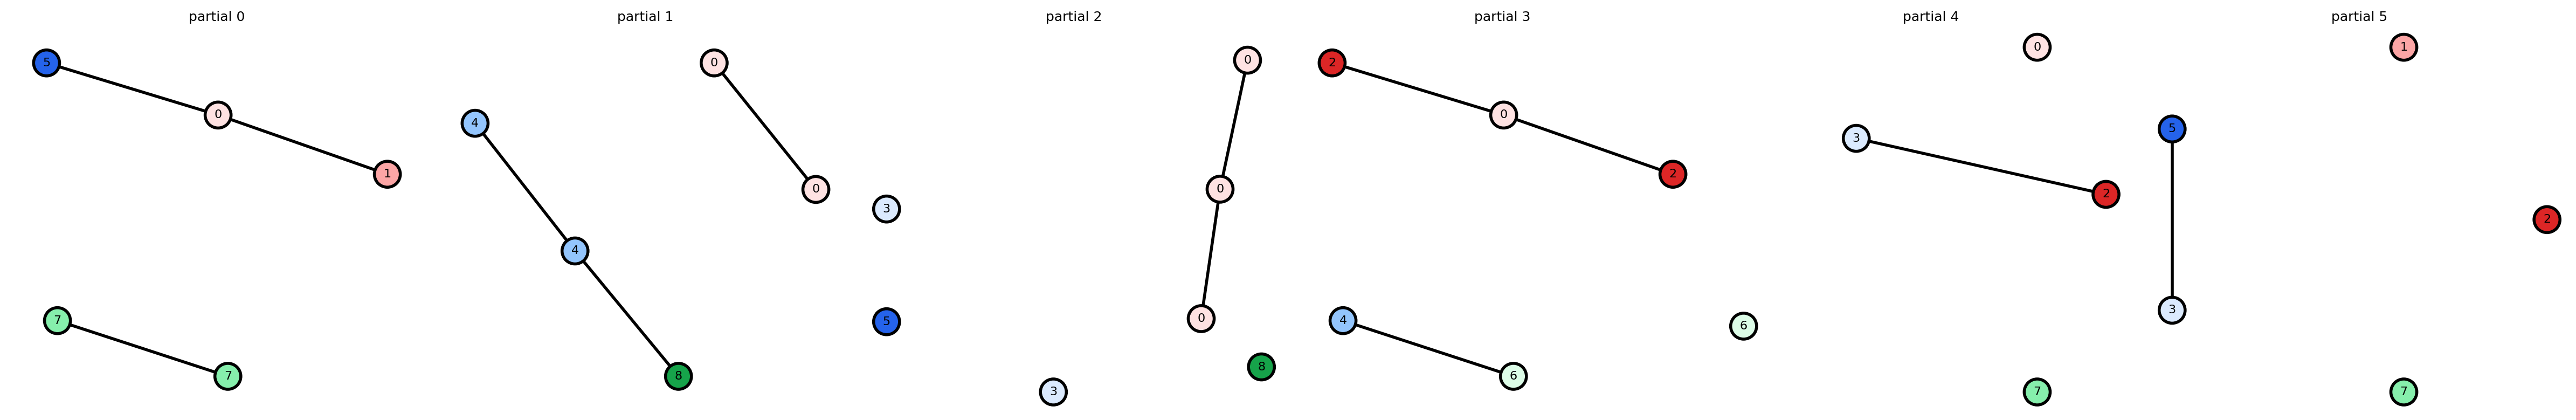

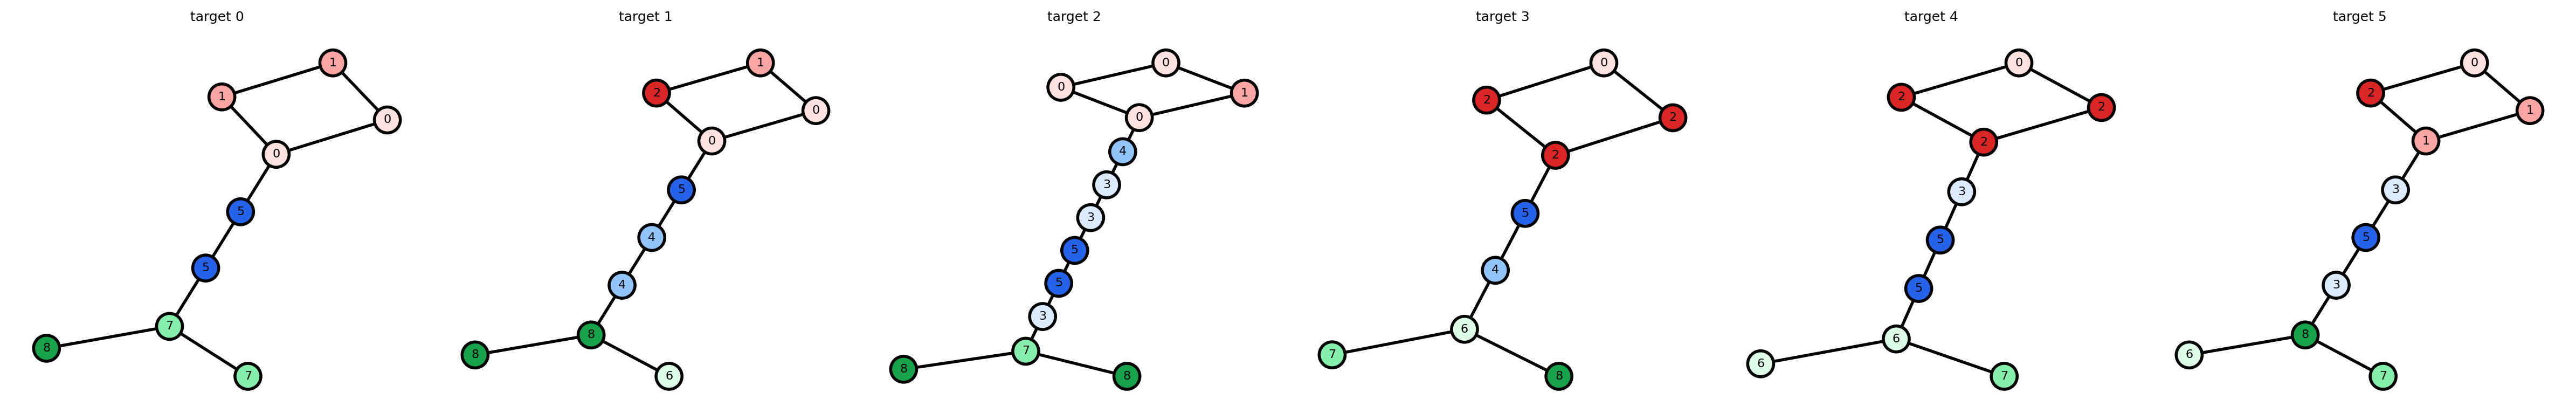

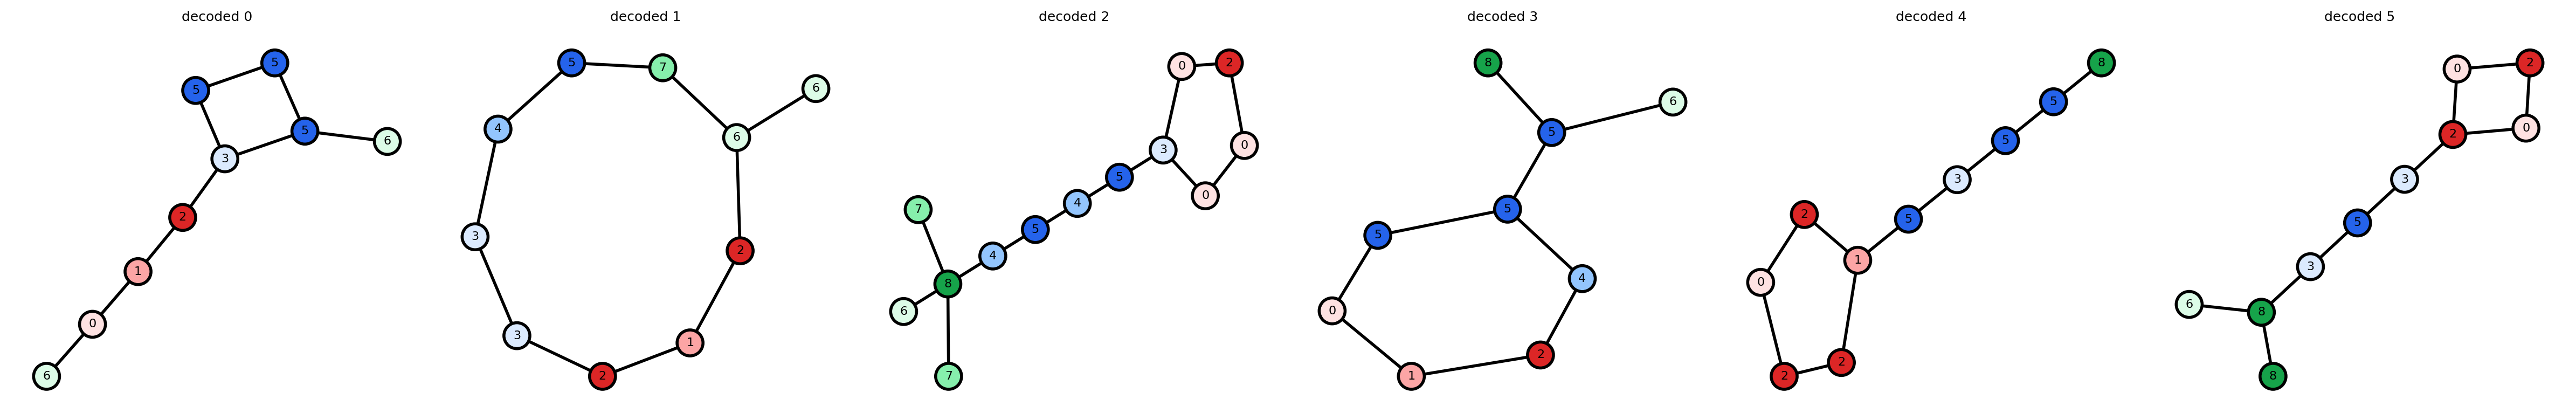

In [8]:
n_eval = 6
eval_indices = np.arange(n_eval, dtype=np.int64)
eval_conditioning = partial_graph_conditioning.take(eval_indices)
decoded_graphs = graph_generator.decode(
    eval_conditioning,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)

plot_artificial_graphs(
    [partial_graphs[idx] for idx in eval_indices],
    n_cols=n_eval,
    titles=[f'partial {idx}' for idx in eval_indices],
)
plot_artificial_graphs(
    [graphs[idx] for idx in eval_indices],
    n_cols=n_eval,
    titles=[f'target {idx}' for idx in eval_indices],
)
plot_artificial_graphs(
    decoded_graphs,
    n_cols=n_eval,
    titles=[f'decoded {idx}' for idx in eval_indices],
)


Decoding 6 conditioning vectors


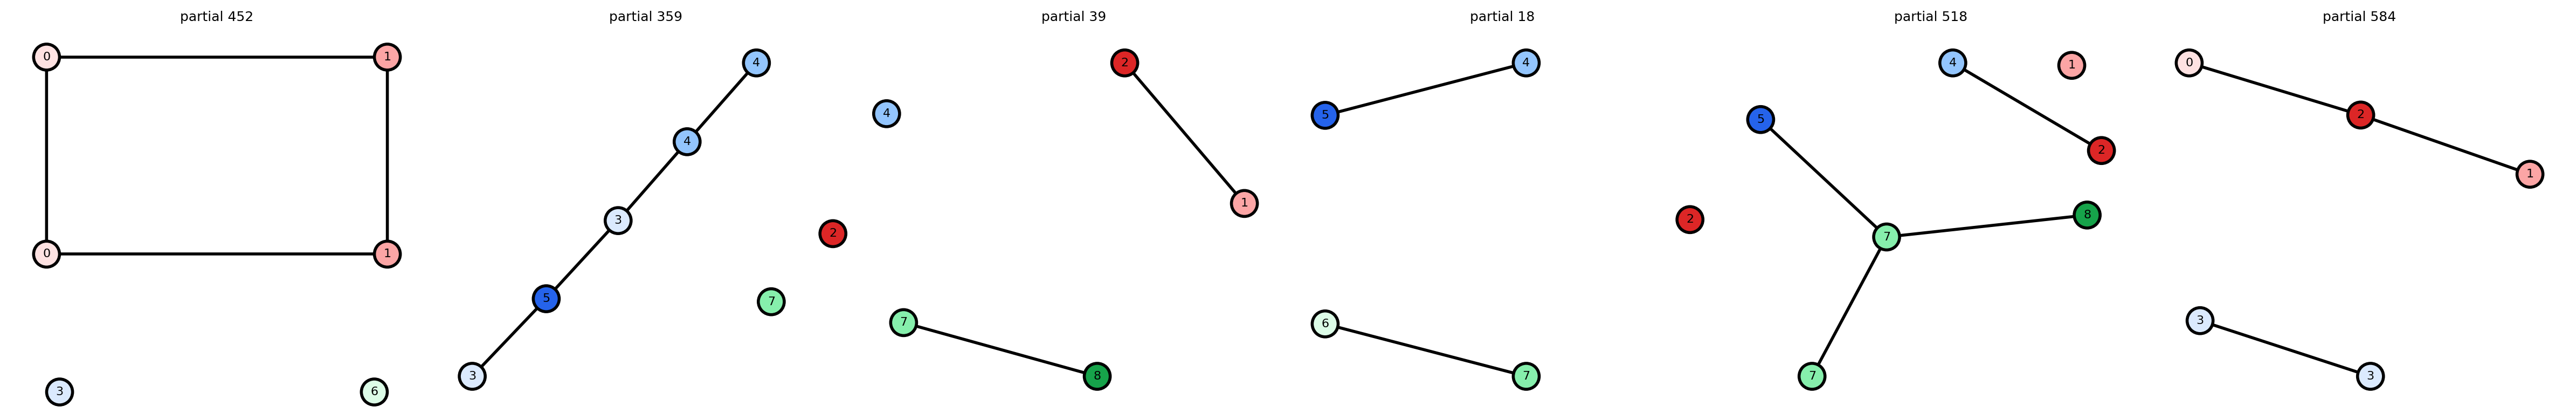

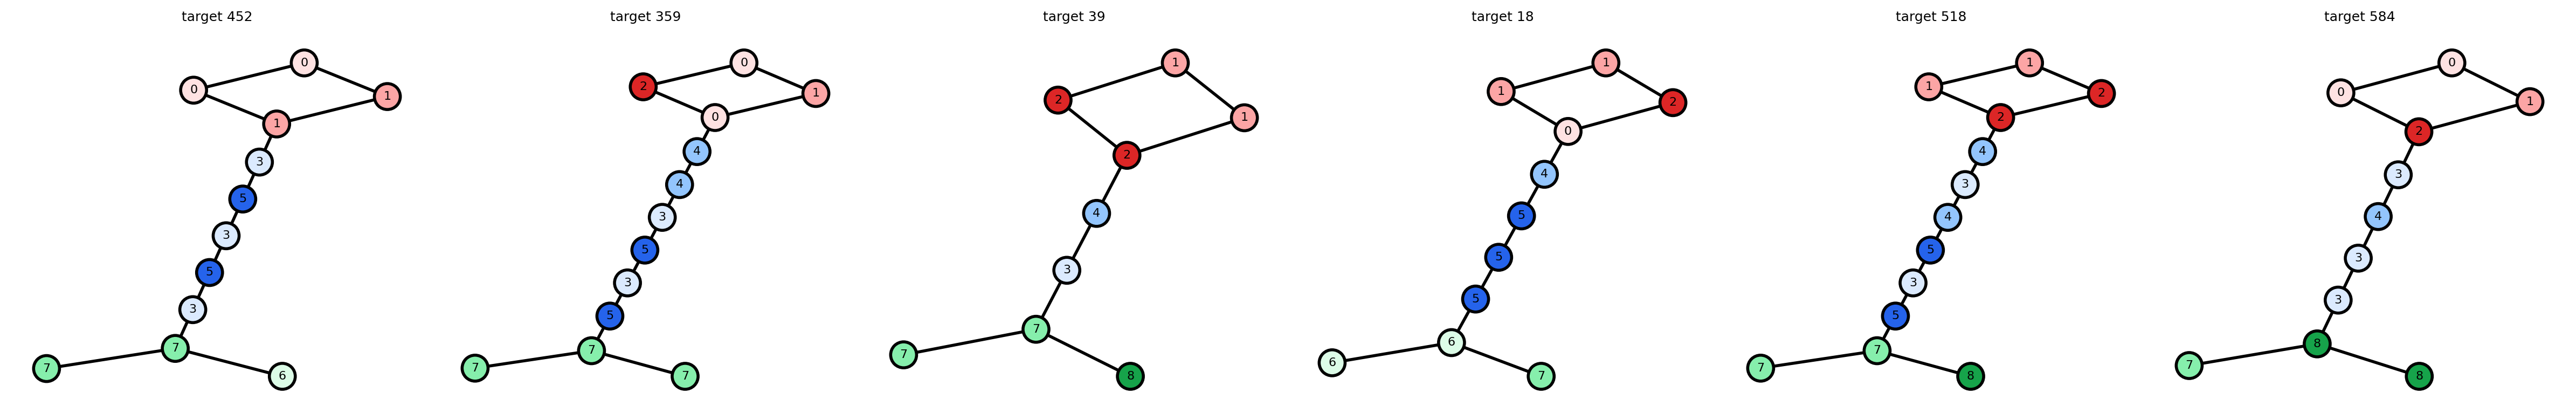

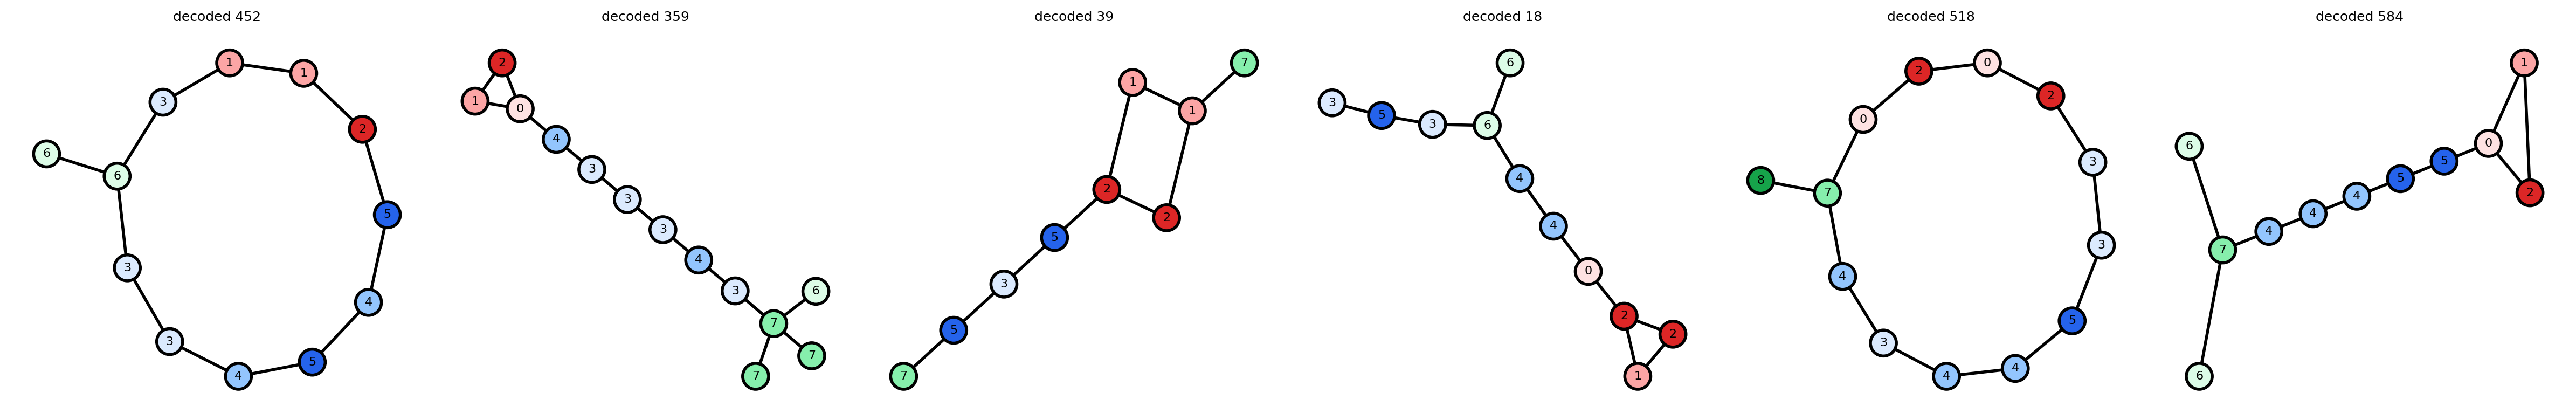

In [9]:
n_random = 6
random_indices = np.random.default_rng(RANDOM_SEED + 1).choice(len(graphs), size=n_random, replace=False)
random_conditioning = partial_graph_conditioning.take(random_indices)
random_decoded = graph_generator.decode(
    random_conditioning,
    apply_feasibility_filtering=False,
    use_ilp_decoder=True,
)

for row_title, graph_list in (
    ('partial', [partial_graphs[int(idx)] for idx in random_indices]),
    ('target', [graphs[int(idx)] for idx in random_indices]),
    ('decoded', random_decoded),
):
    plot_artificial_graphs(
        graph_list,
        n_cols=n_random,
        titles=[f'{row_title} {int(idx)}' for idx in random_indices],
    )
